In [159]:
import os
import pandas as pd
import statsmodels.api as sm
import scipy.stats
import matplotlib.pyplot as plt
from linearmodels import PanelOLS

countries = ["Austria", "Belgium", "Bulgaria", "Croatia", "Czechia", "Denmark", 
             "Estonia", "Finland", "France", "Germany", "Greece", "Hungary", "Ireland", 
             "Italy", "Latvia", "Lithuania", "Luxembourg", "Norway", "Poland",
             "Portugal", "Romania", "Slovakia", "Slovenia", "Spain", "Sweden", "Netherlands",
             #"Germany including former GDR",
             #"Cyprus", "Malta",
             ]

In [160]:
BACKTEST_START = 2018

panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv", index_col=[0, 1])
panel = panel.reorder_levels(['country', 'year']).sort_index()

# ── Data splits ───────────────────────────────────────────────────────────────

hist = panel[panel["demand_ind_TWh"].notna()].copy()
proj = panel[panel["demand_ind_TWh"].isna()].copy()

bt_train = hist[hist.index.get_level_values("year") < BACKTEST_START]
bt_test  = hist[hist.index.get_level_values("year") >= BACKTEST_START]

print(f"Backtest train : 1990 – {BACKTEST_START - 1}  ({len(bt_train)} obs)")
print(f"Backtest test  : {BACKTEST_START} – {hist.index.get_level_values('year').max()}  ({len(bt_test)} obs)")
print(f"Future proj    : {proj.index.get_level_values('year').min()} – {proj.index.get_level_values('year').max()}  ({len(proj)} obs)")

Backtest train : 1990 – 2017  (728 obs)
Backtest test  : 2018 – 2024  (182 obs)
Future proj    : 2025 – 2060  (312 obs)


In [161]:
"""# creating an OLS model for each country
#pop.loc[pd.IndexSlice[:, "Germany"], :]
COUNTRY = "France"
hist = hist.loc[pd.IndexSlice[COUNTRY, :], :]
proj = proj.loc[pd.IndexSlice[COUNTRY, :], :]"""

'# creating an OLS model for each country\n#pop.loc[pd.IndexSlice[:, "Germany"], :]\nCOUNTRY = "France"\nhist = hist.loc[pd.IndexSlice[COUNTRY, :], :]\nproj = proj.loc[pd.IndexSlice[COUNTRY, :], :]'

In [162]:
# model for others (Gebäude):
y_oth = hist[["demand_oth_TWh"]]

x_oth = hist[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC", "cdd_DegreesC"]]

x_oth = sm.add_constant(x_oth)

model_oth = sm.OLS(y_oth, x_oth).fit()
print(model_oth.summary())

                            OLS Regression Results                            
Dep. Variable:         demand_oth_TWh   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     1650.
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        11:23:01   Log-Likelihood:                -4210.8
No. Observations:                 910   AIC:                             8432.
Df Residuals:                     905   BIC:                             8456.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -37.7975      4

In [163]:
hist.demand_oth_TWh

country  year
Austria  1990    22.01700
         1991    23.38100
         1992    23.26400
         1993    24.06200
         1994    23.99500
                   ...   
Sweden   2020    72.86100
         2021    77.35800
         2022    73.16800
         2023    71.28000
         2024    72.26463
Name: demand_oth_TWh, Length: 910, dtype: float64

In [164]:
x_oth_proj = proj[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC", "cdd_DegreesC"]]
x_oth_proj = sm.add_constant(x_oth_proj)

hist["predictions"] = model_oth.predict(x_oth)

proj["demand_oth_TWh"] = model_oth.predict(x_oth_proj)
proj["demand_oth_TWh"]

country  year
Austria  2025    40.791879
         2026    43.529076
         2027    45.301510
         2028    43.928667
         2029    42.369000
                   ...    
Sweden   2040    60.206652
         2045    62.574276
         2050    64.066451
         2055    70.608916
         2060    74.782889
Name: demand_oth_TWh, Length: 312, dtype: float64

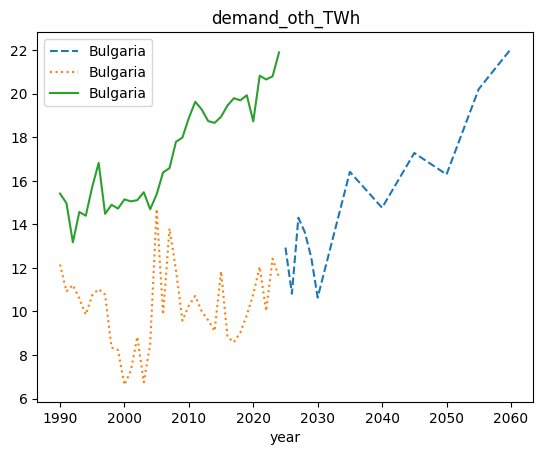

In [165]:
fig, ax = plt.subplots()

for country in ["Bulgaria"]:
    proj.demand_oth_TWh[country, :].plot(ax=ax, label=country, style="--")
    hist.predictions[country, :].plot(ax=ax, label=country, style=":")
    hist.demand_oth_TWh[country, :].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_oth_TWh")
plt.show()

In [166]:
# PanelOLS:
X_panel_hist = sm.add_constant(hist[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC", "cdd_DegreesC"]])
Y_panel = hist[["demand_oth_TWh"]]
#panel_model = PanelOLS(Y_panel, X_panel_hist, entity_effects=True, time_effects=True).fit(cov_type="clustered", cluster_entity=True)
panel_model = PanelOLS(Y_panel, X_panel_hist).fit(cov_type="clustered", cluster_entity=True)


X_panel_proj = sm.add_constant(proj[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC", "cdd_DegreesC"]])

proj["demand_oth_TWh"] = panel_model.predict(X_panel_proj)
hist["panel_predictions"] = panel_model.predict(X_panel_hist)


#proj["demand_oth_TWh"]
print(panel_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:         demand_oth_TWh   R-squared:                        0.8794
Estimator:                   PanelOLS   R-squared (Between):              0.8965
No. Observations:                 910   R-squared (Within):               0.4092
Date:                Wed, May 06 2026   R-squared (Overall):              0.8794
Time:                        11:23:01   Log-likelihood                   -4210.8
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1650.0
Entities:                          26   P-value                           0.0000
Avg Obs:                       35.000   Distribution:                   F(4,905)
Min Obs:                       35.000                                           
Max Obs:                       35.000   F-statistic (robust):             37.041
                            

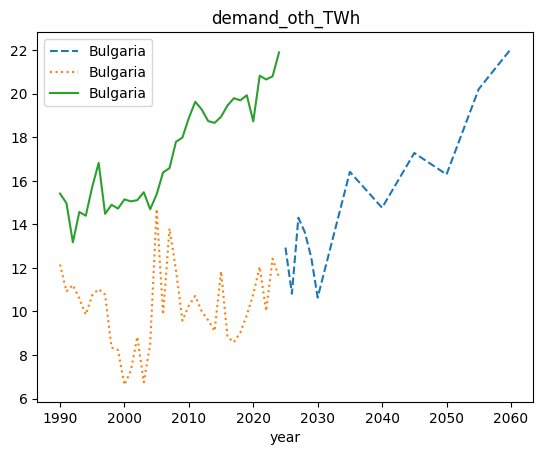

In [167]:
fig, ax = plt.subplots()

COUNTRY = "Bulgaria"

for country in [COUNTRY]:
    proj.demand_oth_TWh[country, :].plot(ax=ax, label=country, style="--")
    hist.predictions[country, :].plot(ax=ax, label=country, style=":")
    hist.demand_oth_TWh[country, :].plot(ax=ax, label=country)

ax.legend()
ax.set_title("demand_oth_TWh")
plt.show()